In [27]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)

In [31]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/paper_bas/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/anti_{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/symmetric_{experiment_name.value}")

assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
all_results_df = all_results_df.loc[all_results_df["num_test_observations"] == 50]
all_results_df.head(3)

solution  \
uuid                                 replication                          
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0            [inf inf inf inf inf]   
                                     1            [inf inf inf inf inf]   
                                     2            [inf inf inf inf inf]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0            0.038702         0.000225   
                                     1            0.001380         0.000213   
                                     2            0.001306         0.000197   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0                  0.000253    0.000013   
                                     1                  0.000195    0.000019   
                                     2                  0.000170    0.000011   

                                                  setup_time  \
uuid                                 replication               
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0                   0.0   
                                     1                   0.0   
                                     2                   0.0   

                                                  log_partition_constant  \
uuid                                 replication                           
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0                          0.279487   
                                     1                          0.279487   
                                     2                          0.279487   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0            [inf, inf, inf, inf, inf, inf, inf, inf, inf, ...   
                                     1            [inf, inf, inf, inf, inf, inf, inf, inf, inf, ...   
                                     2            [inf, inf, inf, inf, inf, inf, inf, inf, inf, ...   

                                                   algorithm  contamination  \
uuid                                 replication                              
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0            kl_dro_bas            0.0   
                                     1            kl_dro_bas            0.0   
                                     2            kl_dro_bas            0.0   

                                                  ... inference lengthscale  \
uuid                                 replication  ...                         
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0            ...     bayes        -1.0   
                                     1            ...     bayes        -1.0   
                                     2            ...     bayes        -1.0   

                                                           likelihood  njobs  \
uuid                                 replication                               
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0            multivariate_normal      1   
                                     1            multivariate_normal      1   
                                     2            multivariate_normal      1   

                                                  num_likelihood_samples  \
uuid                                 replication                           
3f560764-f9c3-41d0-a22e-14ab7bb879d3 0                                25   
                                     1                                25   
                                     2                                25   

                                                 num_observations  \
uuid                         

In [32]:
filter_dgp = "multivariate_normal"  # filter by DGP
results_df = preprocess_results_df(all_results_df, filter_dgp)
results_df.head(3)


solution  \
uuid                                 replication                                                      
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0            [3.453271841568184, 5.57331096049111, 9.540329...   
                                     1            [2.626078097656765, 2.9200502536808775, 6.8052...   
                                     2            [3.5418055124573207, 10.65322218169461, 16.413...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0            0.002121         0.000206   
                                     1            0.001449         0.000215   
                                     2            0.001437         0.000214   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0                  0.000212    0.045496   
                                     1                  0.000198    0.029505   
                                     2                  0.000195    0.032385   

                                                  setup_time  \
uuid                                 replication               
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0                          0.279487   
                                     1                          0.279487   
                                     2                          0.279487   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0            [231.60606540423396, 193.17744809112963, 215.2...   
                                     1            [245.61726588545596, 332.23716528872455, 260.1...   
                                     2            [127.82255695191503, 310.48872878916643, 217.4...   

                                                   algorithm  contamination  \
uuid                                 replication                              
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0            kl_dro_bas            0.0   
                                     1            kl_dro_bas            0.0   
                                     2            kl_dro_bas            0.0   

                                                  ... num_likelihood_samples  \
uuid                                 replication  ...                          
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0            ...                     25   
                                     1            ...                     25   
                                     2            ...                     25   

                                                 num_observations  \
uuid                                 replication                    
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0                         20   
                                     1                         20   
                                     2                         20   

                                                  num_posterior_samples  \
uuid                                 replication                          
7efa7b3f-9892-4190-9fa0-4e6c6022df41 0                                1   
                                     1                                1   
                                     2                                1   

                                         

In [33]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:189: FutureWarning: The provided callable <function mean at 0x7f574f6f1b20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:189: FutureWarning: The provided callable <function std at 0x7f574f6f1c60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm  dgp                 epsilon num_total_samples                       
kl_bdro    multivariate_normal 0.001   25                         281.995012   
                                       100                        280.529216   
                                       900                        281.455140   
                               0.002   25                         281.747588   
                                       100                        281.364715   
...                                                                      ...   
kl_dro_bas multivariate_normal 2.500   100                        337.256431   
                                       900                        351.407618   
                               3.000   25                         302.052279   
                                       100                        337.355553   
                                       900                        351.485476   

                                                          out_of_sample_var  \
algorithm  dgp                 epsilon num_total_samples                      
kl_bdro    multivariate_normal 0.001   25                       3941.056354   
                                       100                      2637.986210   
                                       900                      1888.984072   
                               0.002   25                       3944.811279   
                                       100                      2646.304149   
...                                                                     ...   
kl_dro_bas multivariate_normal 2.500   100                      2335.984657   
                                       900                      1694.411553   
                               3.000   25                       4657.643934   
                                       100                      2369.171325   
                                       900                      1692.667459   

                                                          sum_of_in_group_var  \
algorithm  dgp                 epsilon num_total_samples                        
kl_bdro    multivariate_normal 0.001   25                         1721.403084   
                                       100                        1701.360095   
                                       900                        1695.887113   
                               0.002   25                         1724.262085   
                                       100                        1700.397780   
...                                                                       ...   
kl_dro_bas multivariate_normal 2.500   100                        1735.910564   
                                       900                        1651.025122   
                               3.000   25                         1807.532167   
                                       100                        1748.136830   
                                       900                        1650.664156   

                                                          var_of_in_group_mean  \
algorithm  dgp                 epsilon num_total_samples                         
kl_bdro    multivariate_normal 0.001   25                          2219.653270   
                                       100                          936.626114   
                                       900                          193.096959   
                               0.002   25                          2220.549193   
                                       100                          945.906369   
...                                                                        ...   
kl_dro_bas multivariate_normal 2.500   100                          600.074093   
                                       900                           43.386432   
                               3.000   25                          2850.111768   
                                 

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

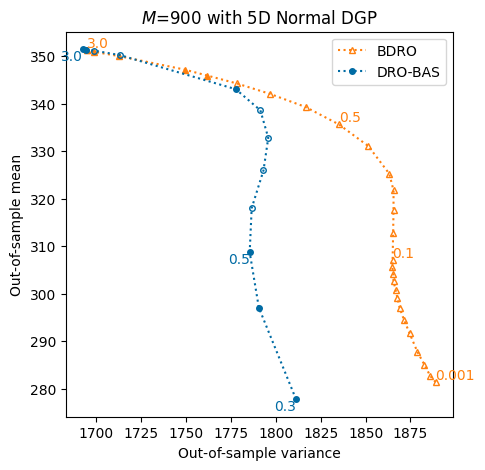

In [42]:
# total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
total_samples_list = [900]
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
axes = np.array([axes])
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)

for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            for k in range(j, len(total_samples_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend()
            axes[j].set_ylabel("Out-of-sample mean")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

# Plot sum of in-group variance and variance of in-group mean
Let $m$ be the number of test observations.
Let $k$ be the number of replications.
Let $\xi_{ij}$ be the $i^{\text{th}}$ test observation for replication $j$.
For a given replication $j$, the in-group mean and variance is
$$\mu_j = \frac{1}{m}\sum_{i=1}^m f(x_j, \xi_{ij}), \hspace{2em} v_j = \frac{1}{m-1}\sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \mu_j \right)^2$$

We define the mean across all replications and all test observations as
$$\bar{\mu} = \frac{1}{mk} \sum_{j=1}^k \sum_{i=1}^m f(x_j, \xi_{ij}).$$

The total variance is defined by $$\frac{1}{mk-1}\sum_{j=1}^k \sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \bar{\mu} \right)^2.$$
This can be decomposed into two terms.
The first is a constant times the sum of the in-group variances:
$$\frac{m-1}{km - 1} \sum^k_{j=1} v_j,$$
and the second term is a constant times the variance of the in-group means:
$$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j).$$


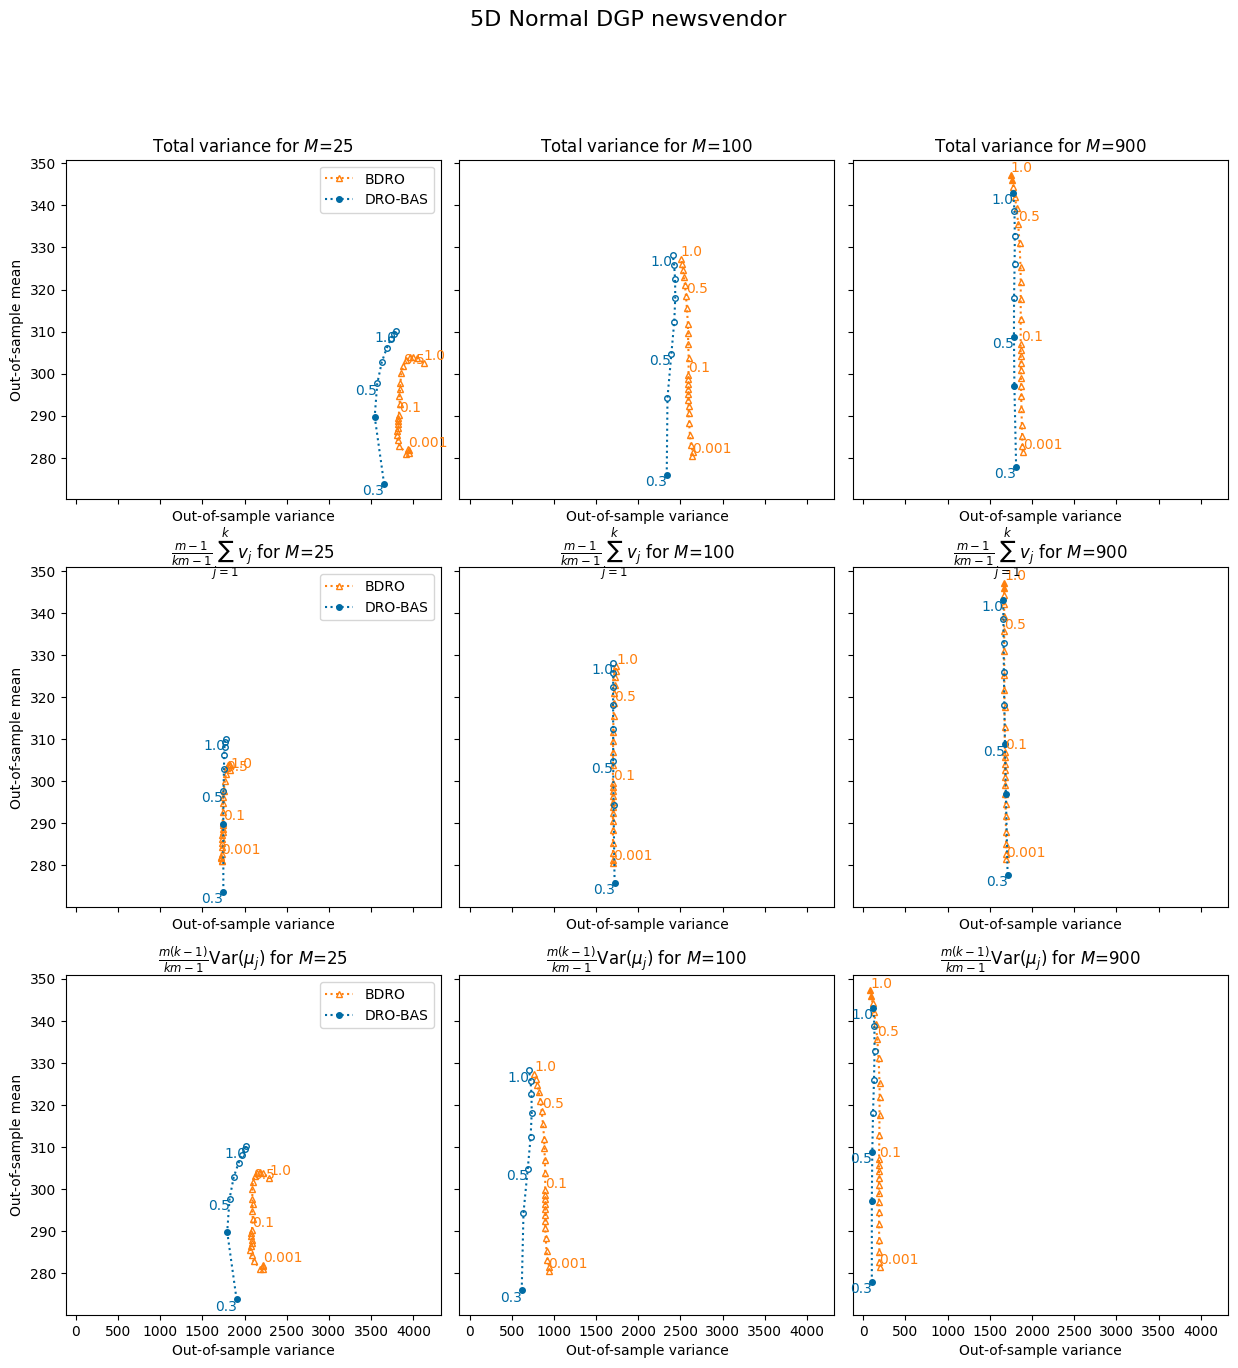

In [35]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = 3
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
fig.suptitle(f"{NiceNameDGP[filter_dgp]} newsvendor", fontsize=16)

nice_var_names = {
    "out_of_sample_var": "Total variance",
    "sum_of_in_group_var": r"$\frac{m-1}{km - 1} \sum^k_{j=1} v_j$",
    "var_of_in_group_mean": r"$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j)$",
}

for i, var_col in enumerate(["out_of_sample_var", "sum_of_in_group_var", "var_of_in_group_mean"]):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :trim_epsilon, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i][j], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, var_col=var_col)
        if j == 0:
            axes[i][j].legend()
            axes[i][j].set_ylabel("Out-of-sample mean")
        axes[i][j].set_title(nice_var_names[var_col] + " for $M$" + f"={total_samples}")
        axes[i][j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

## Solve & sampling time

In [36]:
solve_time_df = get_agg_df(results_df, ["algorithm", "num_total_samples"])
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").to_latex())

\begin{tabular}{lllll}
\toprule
 & \multicolumn{2}{r}{str_solve_time} & \multicolumn{2}{r}{str_sample_time} \\
algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
num_total_samples &  &  &  &  \\
\midrule
25 & 0.1016 (0.0113) & 0.0291 (0.0035) & 0.0042 (0.0003) & 0.0004 (0.0) \\
100 & 0.203 (0.0207) & 0.0773 (0.0091) & 0.0078 (0.0004) & 0.0004 (0.0) \\
900 & 1.1128 (0.0657) & 0.9115 (0.1067) & 0.0224 (0.0011) & 0.0005 (0.0) \\
\bottomrule
\end{tabular}



/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:189: FutureWarning: The provided callable <function mean at 0x7f574f6f1b20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:189: FutureWarning: The provided callable <function std at 0x7f574f6f1c60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


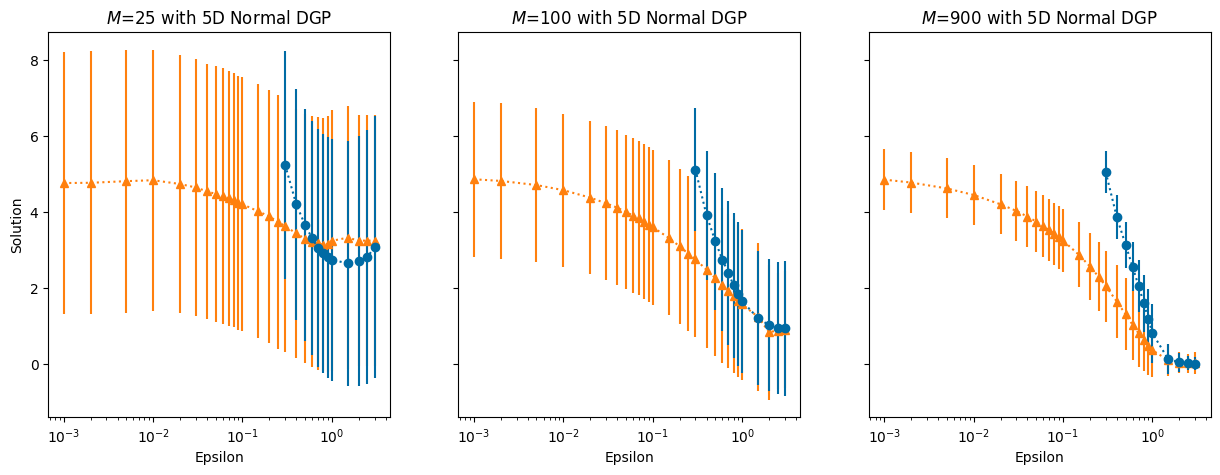

In [41]:
df = results_df.copy()
df["solution"] = df["solution"].map(lambda x: x[4])
nrows = len(dgp_list)
ncols = len(total_samples_list)
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
solution_df = df.groupby(["algorithm", "dgp", "epsilon", "num_total_samples"]).agg({"solution": ["mean", "std"]})
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = solution_df.loc[:, dgp, :, total_samples]
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            axes[j].errorbar(axis_df.loc[algorithm, :].index.get_level_values("epsilon"), axis_df.loc[algorithm, :]["solution"]["mean"], yerr=axis_df.loc[algorithm, :]["solution"]["std"], **algorithm_inference_style(algorithm, "bayes"))
        axes[j].set_xscale("log")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Epsilon")
        if j == 0:
            axes[j].set_ylabel("Solution")